# DeepPCB to PCB v1i Transfer Learning in Google Colab

This notebook prepares a **detection-only transfer-learning workflow** that starts from the completed DeepPCB checkpoint and fine-tunes on `PCB-Defect-Detection.v1i.coco`.

- Source checkpoint: `runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab/weights/best.pt`
- Target dataset config: `configs/pcb_v1i_coco_baseline.yaml`
- Model family: `YOLOv8 detection`
- Target run name: `yolov8n_deeppcb_to_pcb_v1i_transfer_colab`
- Scope: PCB v1i only, no PKU, no DeepPCB merge, no segmentation, no masks, no synthetic data


## Colab Setup Notes

Use one of these project access options:

1. Put the repo in Google Drive and mount Drive in Colab.
2. Clone the repo into `/content/PCB-Defect-Detector`.
3. Upload the project folder manually if needed.

The notebook checks a few common locations and then switches into the repo root automatically.


In [1]:
!pip install -q ultralytics==8.4.14 opencv-python pyyaml matplotlib pandas

import platform
import sys
import torch

print('Python:', sys.version)
print('Platform:', platform.platform())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
!nvidia-smi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:0000:01
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA available: True
Tue May 12 14:28:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N

In [2]:
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted at /content/drive')
else:
    print('Skipping Google Drive mount.')


Mounted at /content/drive
Google Drive mounted at /content/drive


In [3]:
import os
from pathlib import Path

CANDIDATE_ROOTS = [
    Path('/content/drive/MyDrive/PCB-Defect-Detector'),
    Path('/content/drive/MyDrive/github files/PCB-Defect-Detector'),
    Path('/content/PCB-Defect-Detector'),
]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if candidate.exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the PCB-Defect-Detector repo in the expected Colab locations.')

os.chdir(PROJECT_ROOT)
print('PROJECT_ROOT =', PROJECT_ROOT)
!pwd
!ls


PROJECT_ROOT = /content/drive/MyDrive/PCB-Defect-Detector
/content/drive/MyDrive/PCB-Defect-Detector
configs  LICENSE	   notebook   runs     Ultralytics	  yolo26n.pt
data	 MatplotlibConfig  README.md  scripts  UltralyticsConfig  yolov8n.pt


In [4]:
from pathlib import Path

DATA_CONFIG = Path('configs/pcb_v1i_coco_baseline.yaml')
TRAIN_SCRIPT = Path('scripts/pcb_v1i_yolov8_colab_train.py')
SOURCE_CHECKPOINT = Path('runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab/weights/best.pt')

required_paths = [DATA_CONFIG, TRAIN_SCRIPT, SOURCE_CHECKPOINT]
for path in required_paths:
    print(path, 'exists =' , path.exists())

missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required paths: ' + ', '.join(missing))


configs/pcb_v1i_coco_baseline.yaml exists = True
scripts/pcb_v1i_yolov8_colab_train.py exists = True
runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab/weights/best.pt exists = True


In [5]:
import subprocess

prepare_cmd = [
    'python', 'scripts/pcb_v1i_yolov8_colab_train.py',
    '--config', str(DATA_CONFIG),
    '--prepare-only',
]

print('Running:', ' '.join(prepare_cmd))
prepare_result = subprocess.run(prepare_cmd, check=True, text=True, capture_output=True)
print(prepare_result.stdout)
if prepare_result.stderr.strip():
    print(prepare_result.stderr)


Running: python scripts/pcb_v1i_yolov8_colab_train.py --config configs/pcb_v1i_coco_baseline.yaml --prepare-only
CONFIG=/content/drive/MyDrive/PCB-Defect-Detector/configs/pcb_v1i_coco_baseline.yaml
WORKSPACE=/content/drive/MyDrive/PCB-Defect-Detector/data/yolo_ready/pcb_v1i_yolov8_baseline
DATA_YAML=/content/drive/MyDrive/PCB-Defect-Detector/configs/pcb_v1i_yolov8_baseline_data.yaml
MODEL=yolov8n.pt
RUN_NAME=yolov8n_pcb_v1i_baseline_colab
TRAIN_IMAGES=6537
TRAIN_ANNOTATIONS=7398
TRAIN_MISSING_IMAGE_REFS=0
TRAIN_MISSING_IMAGE_FILES=0
TRAIN_INVALID_CATEGORY_IDS=0
TRAIN_MALFORMED_BBOX=0
TRAIN_NONPOSITIVE_BBOX=0
TRAIN_OUT_OF_BOUNDS_BBOX=0
VAL_IMAGES=600
VAL_ANNOTATIONS=674
VAL_MISSING_IMAGE_REFS=0
VAL_MISSING_IMAGE_FILES=0
VAL_INVALID_CATEGORY_IDS=0
VAL_MALFORMED_BBOX=0
VAL_NONPOSITIVE_BBOX=0
VAL_OUT_OF_BOUNDS_BBOX=0
TEST_IMAGES=300
TEST_ANNOTATIONS=351
TEST_MISSING_IMAGE_REFS=0
TEST_MISSING_IMAGE_FILES=0
TEST_INVALID_CATEGORY_IDS=0
TEST_MALFORMED_BBOX=0
TEST_NONPOSITIVE_BBOX=0
TEST_OUT_OF

In [6]:
MODEL = str(SOURCE_CHECKPOINT)
EPOCHS = 10
IMGSZ = 640
BATCH = 16
WORKERS = 2
DEVICE = '0'
FRACTION = 1.0
PATIENCE = 20
PROJECT_DIR = 'runs/pcb_v1i_transfer'
RUN_NAME = 'yolov8n_deeppcb_to_pcb_v1i_transfer_colab'

settings = {
    'model': MODEL,
    'epochs': EPOCHS,
    'imgsz': IMGSZ,
    'batch': BATCH,
    'workers': WORKERS,
    'device': DEVICE,
    'fraction': FRACTION,
    'patience': PATIENCE,
    'project_dir': PROJECT_DIR,
    'run_name': RUN_NAME,
}
settings


{'model': 'runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab/weights/best.pt',
 'epochs': 10,
 'imgsz': 640,
 'batch': 16,
 'workers': 2,
 'device': '0',
 'fraction': 1.0,
 'patience': 20,
 'project_dir': 'runs/pcb_v1i_transfer',
 'run_name': 'yolov8n_deeppcb_to_pcb_v1i_transfer_colab'}

In [7]:
import subprocess

train_cmd = [
    'python', 'scripts/pcb_v1i_yolov8_colab_train.py',
    '--config', str(DATA_CONFIG),
    '--model', MODEL,
    '--epochs', str(EPOCHS),
    '--imgsz', str(IMGSZ),
    '--batch', str(BATCH),
    '--workers', str(WORKERS),
    '--device', DEVICE,
    '--fraction', str(FRACTION),
    '--patience', str(PATIENCE),
    '--project', PROJECT_DIR,
    '--name', RUN_NAME,
]

print('Running:', ' '.join(train_cmd))
train_result = subprocess.run(train_cmd, check=True, text=True, capture_output=True)
print(train_result.stdout)
if train_result.stderr.strip():
    print(train_result.stderr)
print(train_result)


Running: python scripts/pcb_v1i_yolov8_colab_train.py --config configs/pcb_v1i_coco_baseline.yaml --model runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab/weights/best.pt --epochs 10 --imgsz 640 --batch 16 --workers 2 --device 0 --fraction 1.0 --patience 20 --project runs/pcb_v1i_transfer --name yolov8n_deeppcb_to_pcb_v1i_transfer_colab
CONFIG=/content/drive/MyDrive/PCB-Defect-Detector/configs/pcb_v1i_coco_baseline.yaml
WORKSPACE=/content/drive/MyDrive/PCB-Defect-Detector/data/yolo_ready/pcb_v1i_yolov8_baseline
DATA_YAML=/content/drive/MyDrive/PCB-Defect-Detector/configs/pcb_v1i_yolov8_baseline_data.yaml
MODEL=runs/detect/runs/deeppcb_baseline/yolov8n_deeppcb_baseline_colab/weights/best.pt
RUN_NAME=yolov8n_deeppcb_to_pcb_v1i_transfer_colab
TRAIN_IMAGES=6537
TRAIN_ANNOTATIONS=7398
TRAIN_MISSING_IMAGE_REFS=0
TRAIN_MISSING_IMAGE_FILES=0
TRAIN_INVALID_CATEGORY_IDS=0
TRAIN_MALFORMED_BBOX=0
TRAIN_NONPOSITIVE_BBOX=0
TRAIN_OUT_OF_BOUNDS_BBOX=0
VAL_IMAGES=600
VAL_ANNOTATIONS=674

In [8]:
from pathlib import Path

candidate_run_dirs = [
    Path(PROJECT_DIR) / RUN_NAME,
    Path('runs/detect') / PROJECT_DIR / RUN_NAME,
]

run_dir = None
for candidate in candidate_run_dirs:
    if candidate.exists():
        run_dir = candidate
        break

if run_dir is None:
    raise FileNotFoundError('Could not locate the transfer run directory.')

best_weights = run_dir / 'weights' / 'best.pt'
last_weights = run_dir / 'weights' / 'last.pt'
results_csv = run_dir / 'results.csv'
args_yaml = run_dir / 'args.yaml'
prediction_dir = Path('data/inspection_outputs') / f'{RUN_NAME}_predictions'

print('RUN_DIR =', run_dir)
print('BEST_WEIGHTS exists =', best_weights.exists())
print('LAST_WEIGHTS exists =', last_weights.exists())
print('RESULTS_CSV exists =', results_csv.exists())
print('ARGS_YAML exists =', args_yaml.exists())
print('PREDICTION_DIR exists =', prediction_dir.exists())


RUN_DIR = runs/detect/runs/pcb_v1i_transfer/yolov8n_deeppcb_to_pcb_v1i_transfer_colab
BEST_WEIGHTS exists = True
LAST_WEIGHTS exists = True
RESULTS_CSV exists = True
ARGS_YAML exists = True
PREDICTION_DIR exists = True


Prediction images found: 8
data/inspection_outputs/yolov8n_deeppcb_to_pcb_v1i_transfer_colab_predictions/missing_hole04_y0_x1080_jpg.rf.79b3881c050909c662b3252c43b3536d.jpg


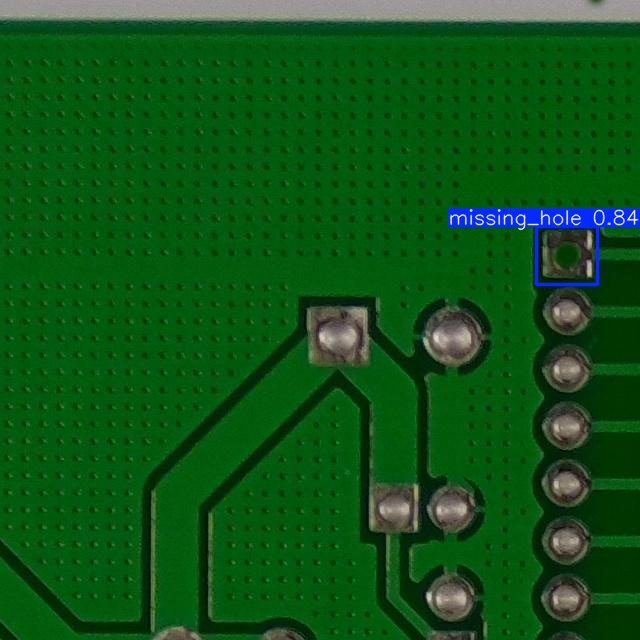

data/inspection_outputs/yolov8n_deeppcb_to_pcb_v1i_transfer_colab_predictions/missing_hole101_y1080_x1080_jpg.rf.824d8fd0828fed91263b7ee42d18e56d.jpg


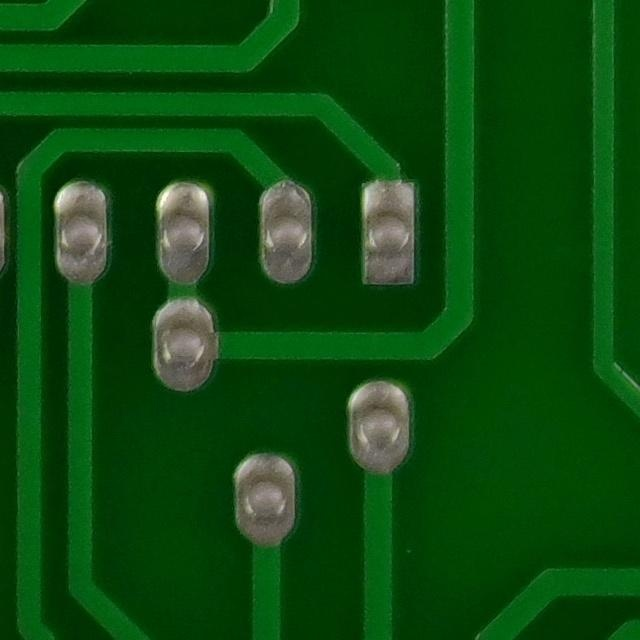

data/inspection_outputs/yolov8n_deeppcb_to_pcb_v1i_transfer_colab_predictions/missing_hole104_y0_x1080_jpg.rf.39e80e2e23acb3accbf83229f234ab00.jpg


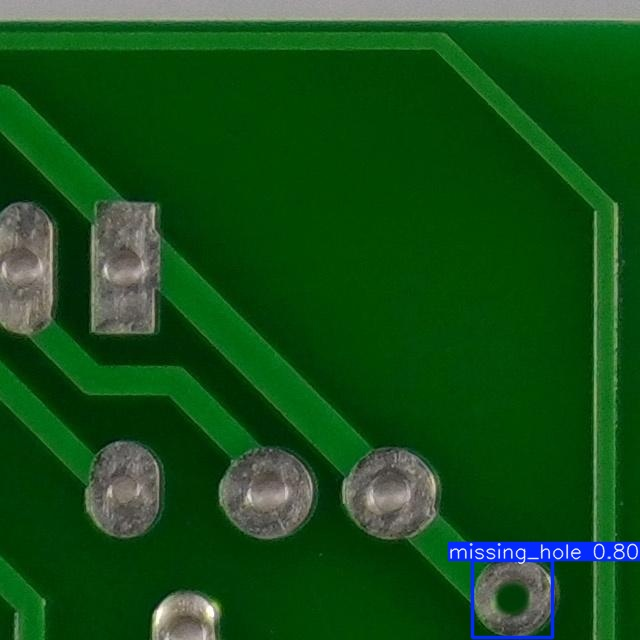

data/inspection_outputs/yolov8n_deeppcb_to_pcb_v1i_transfer_colab_predictions/missing_hole105_y540_x0_jpg.rf.36d5414c91bd866e3bf6ec29b4f2e509.jpg


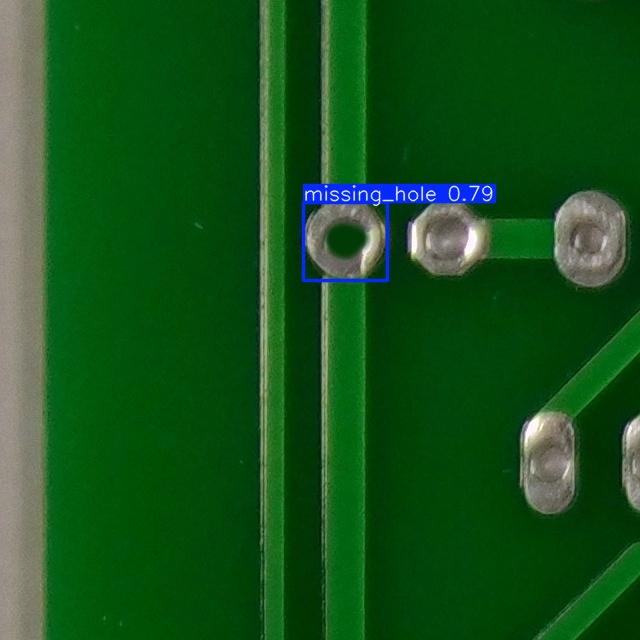

In [9]:
from IPython.display import Image, display
from pathlib import Path

prediction_dir = Path('data/inspection_outputs') / f'{RUN_NAME}_predictions'
image_paths = sorted(prediction_dir.glob('*.jpg')) + sorted(prediction_dir.glob('*.png'))

print('Prediction images found:', len(image_paths))
for image_path in image_paths[:4]:
    print(image_path)
    display(Image(filename=str(image_path)))
